In [50]:
import pandas as pd

In [51]:
columns_headers = [
    "time", "gender", "highschool_grade", "study_year","faculty","ung_grade_2023","accomodation","allowance","scholarship","study_hours",
    "party_week","drinks_night","missed_classes", "failed_classes", "in_relationship","parent_approve","relation_parent"
]
student_df = pd.read_csv("student_survey.csv", names=columns_headers, header=0)

In [52]:
student_df.drop("time", axis = 1, inplace= True)

In [53]:
student_df.head()

,gender,highschool_grade,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


## Exploratory Data Analysis EDA

basic info [shape, dtypes, info]

distributions counts

target specific, exploration and visualization

correlation or chi-square

In [54]:
student_df.shape    

(406, 16)

In [55]:
student_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            404 non-null    str    
 1   highschool_grade  399 non-null    float64
 2   study_year        333 non-null    str    
 3   faculty           399 non-null    str    
 4   ung_grade_2023    320 non-null    float64
 5   accomodation      383 non-null    str    
 6   allowance         375 non-null    str    
 7   scholarship       398 non-null    str    
 8   study_hours       403 non-null    str    
 9   party_week        404 non-null    str    
 10  drinks_night      404 non-null    str    
 11  missed_classes    403 non-null    str    
 12  failed_classes    403 non-null    str    
 13  in_relationship   403 non-null    str    
 14  parent_approve    402 non-null    str    
 15  relation_parent   403 non-null    str    
dtypes: float64(2), str(14)
memory usage: 50.9 KB


In [56]:
student_df.isna().sum()

gender               2
highschool_grade     7
study_year          73
faculty              7
ung_grade_2023      86
accomodation        23
allowance           31
scholarship          8
study_hours          3
party_week           2
drinks_night         2
missed_classes       3
failed_classes       3
in_relationship      3
parent_approve       4
relation_parent      3
dtype: int64

--description--

gender distribution in the dataset

In [57]:
student_df.gender.value_counts(normalize=True)

gender
Male      0.534653
Female    0.465347
Name: proportion, dtype: float64

in the given study, 53.5%students are male and 46.5% students are female.

In [58]:
## relation between parent approval and parent relationship

table = pd.crosstab(student_df.parent_approve, student_df.relation_parent)
table = table[["Distant","Fair","Close","Very close",]]
table.T

parent_approve,No,Yes
relation_parent,,
Distant,1,1
Fair,9,25
Close,18,79
Very close,20,248


<Axes: title={'center': 'Relation between parent approval and parent relationship'}, xlabel='Degree of Parent Relationship', ylabel='Student Count'>

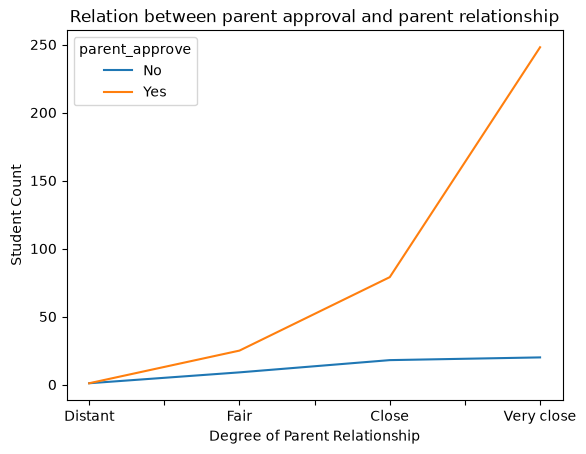

In [59]:
table.T.plot(
    kind = "line",
    title = "Relation between parent approval and parent relationship",
    ylabel = "Student Count",
    xlabel = "Degree of Parent Relationship"
     )

## Relation between parent relationship and grade in highschool

In [60]:
group_parent_relation = student_df.groupby(by = "relation_parent")

In [61]:
relation = group_parent_relation["highschool_grade"].aggregate(["min", "max", "mean"])

In [62]:
relation

,min,max,mean
relation_parent,,,
Close,60.0,98.33,77.690000
Distant,85.0,98.00,91.500000
Fair,55.0,95.50,78.357143
Very close,34.0,99.00,77.960114


In [63]:
relation = relation.T[["Distant","Fair","Close","Very close"]]

<Axes: xlabel='relation_parent'>

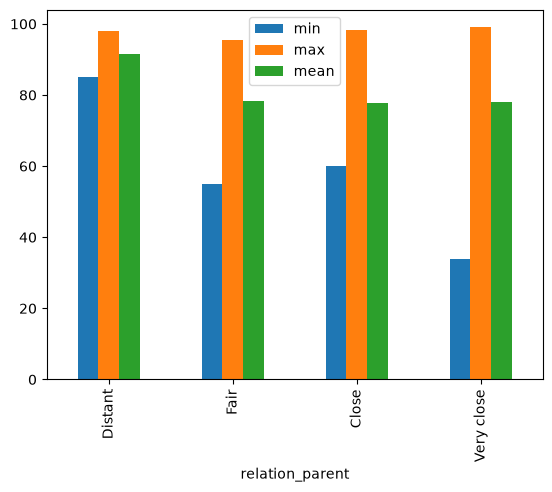

In [64]:
relation.T.plot(kind = "bar")

As shown in the chart, the minimum values appear to have an inverse relation with parent relation , whereas the mean score for the distant relationship appears to be higher than those of the other categories.  

<Axes: xlabel='highschool_grade', ylabel='ung_grade_2023'>

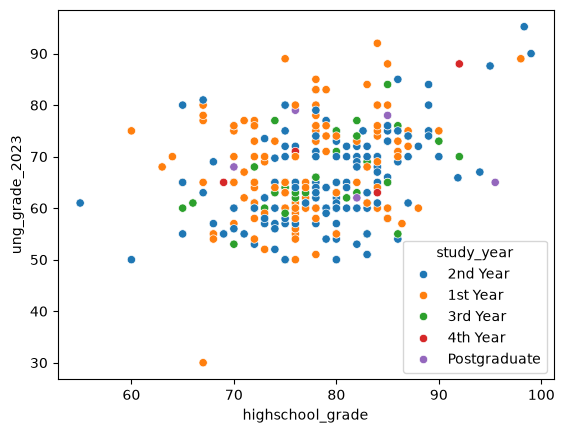

In [65]:
## Relationship between highschool grade and UNG grade
import seaborn as sns

sns.scatterplot(student_df, x = "highschool_grade", y = "ung_grade_2023", hue = "study_year")

In [66]:
student_df["highschool_grade"].corr(student_df["ung_grade_2023"])

np.float64(0.29910363012959096)

In [67]:
student_df.scholarship.value_counts()

scholarship
No                     352
Yes (NSFAS, etc...)     46
Name: count, dtype: int64

In [68]:
student_df.allowance.value_counts()

allowance
R 4001- R 5000     159
R 5001 - R 6000    101
R 6001 - R 7000     58
R 7001 - R 8000     30
R 8000+             27
Name: count, dtype: int64

In [69]:
student_df.ung_grade_2023.mean()

np.float64(66.26846875)

In [70]:
## Check for Duplicates
student_df[student_df.duplicated()]

,gender,highschool_grade,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
144,Female,85.0,2nd Year,Economic & Management Sciences,73.0,Private accommodation/ stay with family/friends,R 5001 - R 6000,No,8+,2,1-3,4+,0,Yes,Yes,Very close
232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
325,Male,71.0,NaN,Economic & Management Sciences,NaN,Private accommodation/ stay with family/friends,R 4001- R 5000,"Yes (NSFAS, etc...)",3-5,2,8+,1,0,Yes,Yes,Very close


In [72]:
## Entire Row is Null
student_df[student_df.isna().sum(axis = 1) > (len(student_df.columns)//2)]

,gender,highschool_grade,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data Manipulation / Cleaning / Transfomring / Processing

Unwanted columns removal

Duplicated value removal

Null value Handling

outlier Handling

Feature Engineering

Encoding

Normalization (Post -processing)

In [73]:
student_df.shape

(406, 16)

In [74]:
# Removing Duplicated Rows
student_df.drop_duplicates(inplace = True)

In [75]:
student_df.shape

(403, 16)

In [76]:
# Counting Null Values
student_df.isna().sum()

gender               1
highschool_grade     6
study_year          71
faculty              6
ung_grade_2023      84
accomodation        22
allowance           30
scholarship          7
study_hours          2
party_week           1
drinks_night         1
missed_classes       2
failed_classes       2
in_relationship      2
parent_approve       3
relation_parent      2
dtype: int64

In [77]:
# Removing Rows with 60% / 9 null values
student_df.dropna(axis = 0, thresh = 6, inplace= True)

In [78]:
student_df.isna().sum()

gender               0
highschool_grade     5
study_year          70
faculty              5
ung_grade_2023      83
accomodation        21
allowance           29
scholarship          6
study_hours          1
party_week           0
drinks_night         0
missed_classes       1
failed_classes       1
in_relationship      1
parent_approve       2
relation_parent      1
dtype: int64

In [79]:
## Domain Expert
## Remove Null Values or Imputation (Mode)
## Null as Feature